In [16]:
#импортируем нужнуе библиотеки и данные
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df_p = pd.read_csv('/content/drive/MyDrive/Products.csv', sep = ';')
df_c = pd.read_csv('/content/drive/MyDrive/Customers.csv', sep = ';')
df_o = pd.read_csv('/content/drive/MyDrive/Orders.csv', sep = ';', parse_dates=['OrderDate', 'RequiredDate', 'ShippedDate'])
df_od = pd.read_csv('/content/drive/MyDrive/Order_details.csv', sep = ';')
df_e = pd.read_excel('/content/drive/MyDrive/Employees.xlsx')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Визуализация в pandas

array([[<Axes: title={'center': 'ProductID'}>,
        <Axes: title={'center': 'UnitPrice'}>],
       [<Axes: title={'center': 'CategoryID'}>, <Axes: >]], dtype=object)

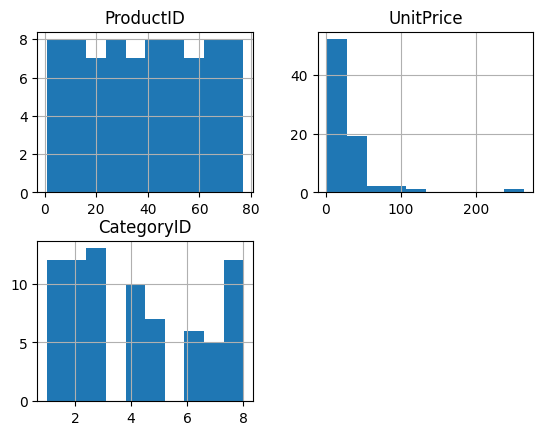

In [2]:
#строим гистограмму для всех столбцов с числовым типом данных (int64, float64)
df_p.hist()

<Axes: >

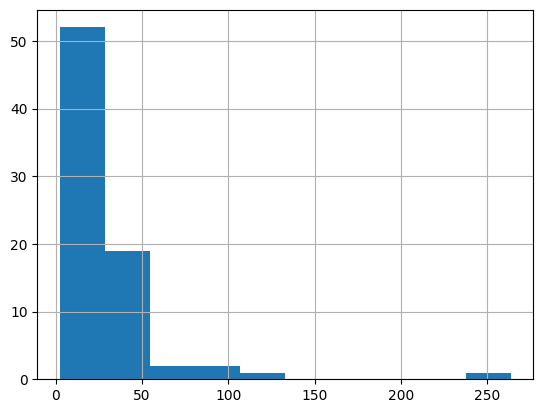

In [3]:
#строим гистограмму для стоймости
df_p['UnitPrice'].hist()

In [4]:
#воспроизводим гистограмму в числах
#разбиваем цену на 10 бинов
df_p['UnitPrice_bin'] = pd.cut(df_p['UnitPrice'],10)

#это тоже самое что и гистограмма
df_p.groupby('UnitPrice_bin').ProductID.count()

<ipython-input-4-0595c09f0989>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_p.groupby('UnitPrice_bin').ProductID.count()


,ProductID
UnitPrice_bin,
"(2.239, 28.6]",52
"(28.6, 54.7]",19
"(54.7, 80.8]",2
"(80.8, 106.9]",2
"(106.9, 133.0]",1
"(133.0, 159.1]",0
"(159.1, 185.2]",0
"(185.2, 211.3]",0
"(211.3, 237.4]",0


<Axes: >

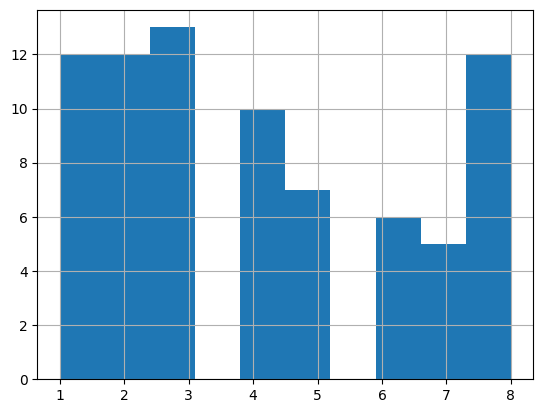

In [5]:
#гистограмма для CategotyID
df_p['CategoryID'].hist()

In [6]:
#это то же самое в числах
df_p.groupby('CategoryID').ProductID.count()

,ProductID
CategoryID,
1,12
2,12
3,13
4,10
5,7
6,6
7,5
8,12


<Axes: >

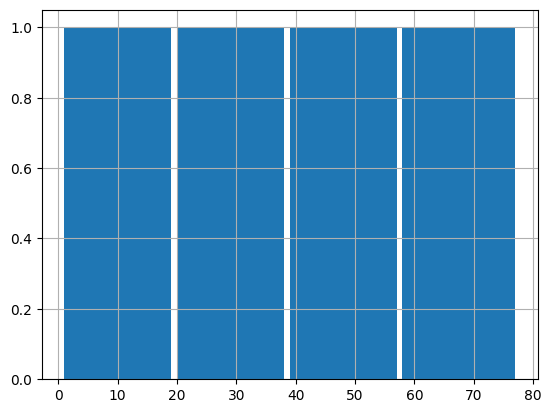

In [7]:
#гистограмма для productID не информативна
df_p['ProductID'].hist(bins =80)

In [9]:
#попробуем построить гистограмму для датафрейма с клиентами

df_c

,CustomerID,ContactName,ContactTitle,Phone,Address
0,ALFKI,Maria Anders,Sales Representative,030-0074321,Obere Str. 57
1,ANATR,Ana Trujillo,Owner,(5) 555-4729,Avda. de la Constitucion 2222
2,ANTON,Antonio Moreno,Owner,(5) 555-3932,Mataderos 2312
3,AROUT,Thomas Hardy,Sales Representative,(171) 555-7788,120 Hanover Sq.
4,BERGS,Christina Berglund,Order Administrator,0921-12 34 65,Berguvsv?gen 8
...,...,...,...,...,...
86,WARTH,Pirkko Koskitalo,Accounting Manager,981-443655,Torikatu 38
87,WELLI,Paula Parente,Sales Manager,(14) 555-8122,"Rua do Mercado, 12"
88,WHITC,Karl Jablonski,Owner,(206) 555-4112,305 - 14th Ave. S. Suite 3B
89,WILMK,Matti Karttunen,Owner/Marketing Assistant,90-224 8858,Keskuskatu 45


In [10]:
df_c.hist()

ValueError: hist method requires numerical or datetime columns, nothing to plot.

In [ ]:
#получаем ошибку, которая связана с тем, что метод hist не нашел в датафрейме числовых значений

<Axes: >

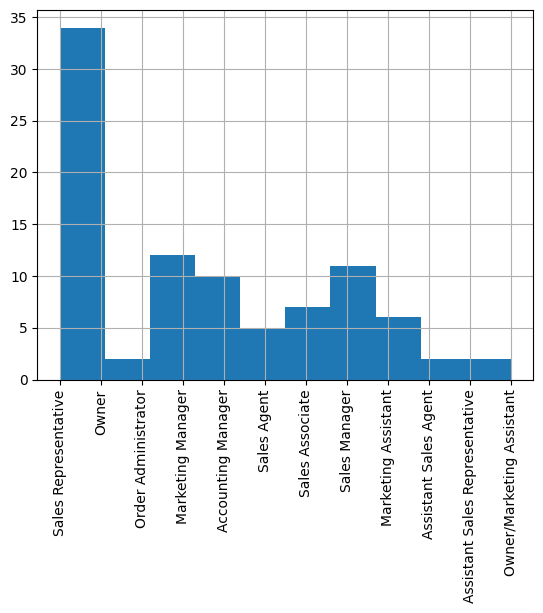

In [12]:
#но если указать конкретный столбец, то все будет работать и выводить по каждой профессии количество человек
df_c['ContactTitle'].hist(xrot = 'vertical') #давили параметр подписей значений для оси Х, чтобы было читабельно

<Axes: >

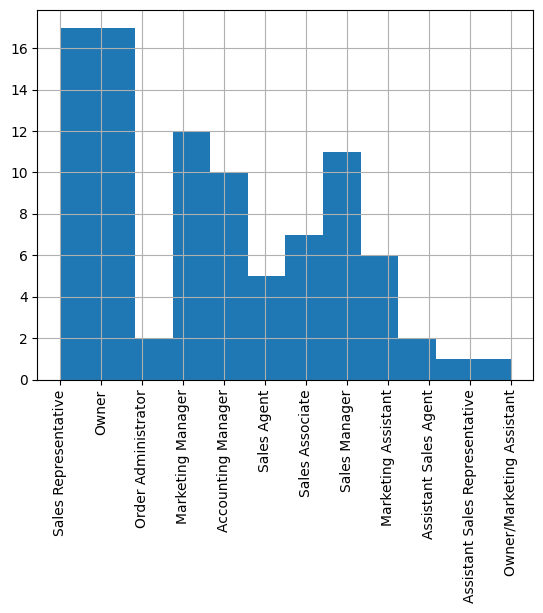

In [13]:
#обратите внимание, что некоторые должности визуально смещены на графике
#не понятно, сколько человек с должностью Owner, например
#если указать вручную количесвто бинов для гистограммы, то она станет ровнее

#разбиваем на 12 бинов (по количеству должностей)
df_c['ContactTitle'].hist(xrot = 'vertical', bins = 12)

In [14]:
#тоже самое
df_c.groupby('ContactTitle').CustomerID.count()

,CustomerID
ContactTitle,
Accounting Manager,10
Assistant Sales Agent,2
Assistant Sales Representative,1
Marketing Assistant,6
Marketing Manager,12
Order Administrator,2
Owner,17
Owner/Marketing Assistant,1
Sales Agent,5


<Axes: xlabel='ContactTitle'>

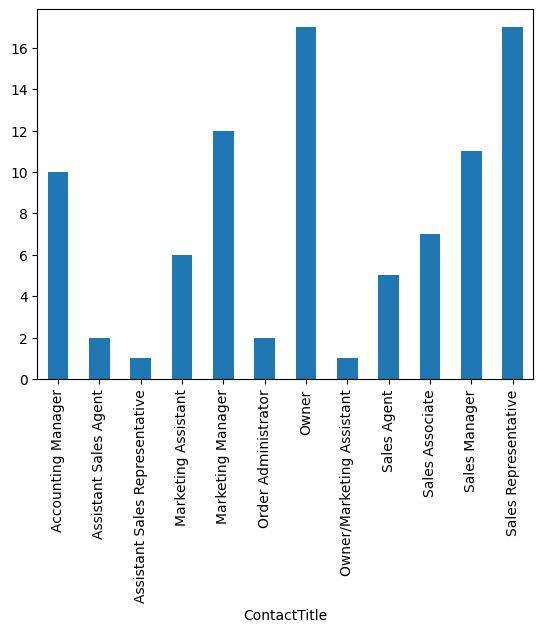

In [15]:
#можно визуализировать df_c.groupby('ContactTitle').CustomerID.count()  с помощью метода .plot()
#, выбрав тип диаграммы - столбчатая
df_c.groupby('ContactTitle').CustomerID.count().plot(kind= 'bar')

In [17]:
#выводим 5 строк с df_o
df_o.head()

,OrderID,CustomerID,EmployeeID,OrderDate,RequiredDate,ShippedDate,Freight
0,10248,VINET,5,1996-07-04,1996-08-01,1996-07-16,32.38
1,10249,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,11.61
2,10250,HANAR,4,1996-07-08,1996-08-05,1996-07-12,65.83
3,10251,VICTE,3,1996-07-08,1996-08-05,1996-07-15,41.34
4,10252,SUPRD,4,1996-07-09,1996-08-06,1996-07-11,51.30


In [18]:
#извлекаем из даты заказа месяц, год, неделю
df_o['month'] = df_o['OrderDate'].dt.month
df_o['year'] = df_o['OrderDate'].dt.year
df_o['week'] = df_o['OrderDate'].dt.isocalendar().week

In [19]:
#расчитываем чистую выручку
df_od['revenue'] = df_od['UnitPrice']*df_od['Quantity']*(1-df_od['Discount'])

In [20]:
#считаем чистую выручку по каждому заказу и записываем в новый датафрейм
df_od_final = df_od.groupby('OrderID').revenue.sum().reset_index()

In [21]:
#добавляем в df_o чистую выручку
df_o = df_o.merge(df_od_final)

<Axes: xlabel='year'>

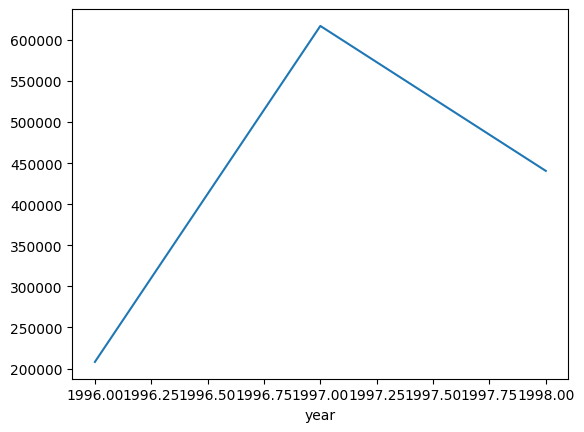

In [25]:
#самый простой граффик
#по умолчанию линейная диаграмма
df_o.groupby('year').revenue.sum().plot()

<Axes: xlabel='year'>

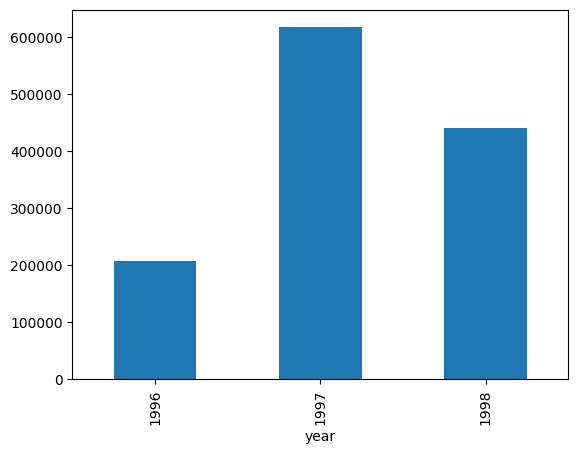

In [23]:
#столбчатая диаграмма
df_o.groupby('year').revenue.sum().plot(kind= 'bar')

<Axes: xlabel='year,month'>

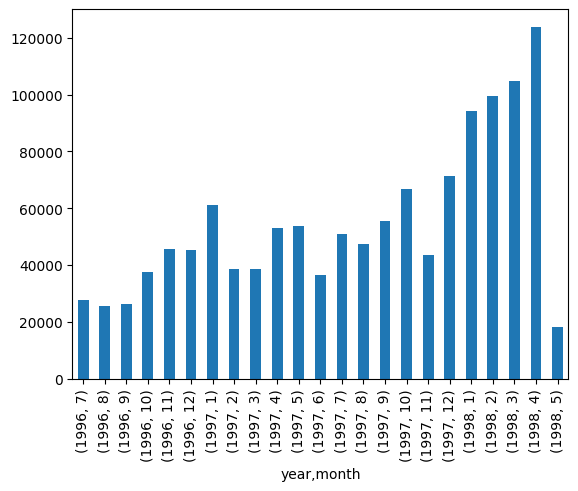

In [26]:
#увеличим детализацию. Добавим разрез месяц.
df_o.groupby(['year','month']).revenue.sum().plot(kind= 'bar')

In [27]:
#но чаще нам нужно сравнение периода к периоду
#расчитаем чистую выручку по месяцам для 1997 и для 1998 года. Запишем расчеты в новые датафреймы
df_o_1997 = df_o[df_o.year== 1997].groupby('month').revenue.sum().reset_index().copy()
df_o_1998 = df_o[df_o.year== 1998].groupby('month').revenue.sum().reset_index().copy()
#переименнуем столбцы с выручкой
df_o_1998 = df_o_1998.rename(columns = {'revenue':'1998'})
df_o_1997 = df_o_1997.rename(columns = {'revenue':'1997'})

In [28]:
#объединим в один датафрейм, в котором будет показано, какая выручка в месяц была в для 1997 и для 1998 года
df_f = df_o_1997.merge(df_o_1998, how ='left',on = 'month')

In [29]:
#смотрим что получилось
df_f

,month,1997,1998
0,1,61258.0700,94222.1105
1,2,38483.6350,99415.2875
2,3,38547.2200,104854.1550
3,4,53032.9525,123798.6825
4,5,53781.2900,18333.6305
5,6,36362.8025,NaN
6,7,51020.8575,NaN
7,8,47287.6700,NaN
8,9,55629.2425,NaN
9,10,66749.2260,NaN


<Axes: >

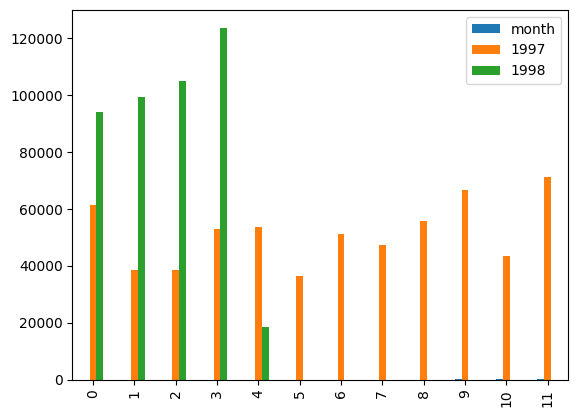

In [30]:
#строим граффик
df_f.plot(kind= 'bar')

<Axes: >

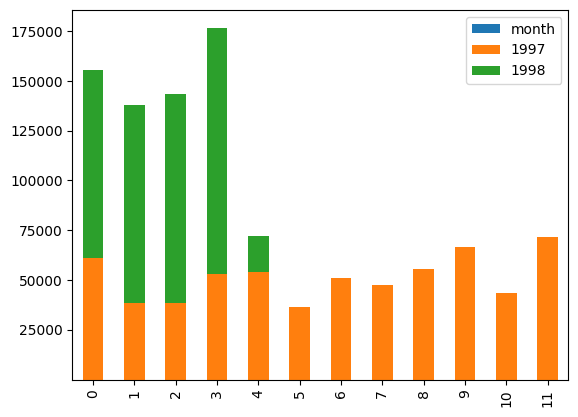

In [31]:
#выводим выручку обоих годов в одном столбце
df_f.plot(kind= 'bar', stacked  = True)

На верхних двух графиках, несмотря на то что нумерация месяцев от 1 до 12, в подписях по оси х нумерация начинается с нуля. Почему так происходит?

На самом деле .plot() посчитал количество строк в датафрейме и вывел их индексы в подписях столбцов. При этом по оси Y три показателя: чистый оборот за 1997 год, чистый оборот за 1998 год и даже месяцы. Из-за того что оборот высокий, а значения месяцев всего от 1 до 12, то месяцы не видны на графике (синей заливки не видно из-за масштаба). Посчитаем вместо чистого оборота кол-во заказов по месяцам, чтобы уменишить масштаб.

<Axes: >

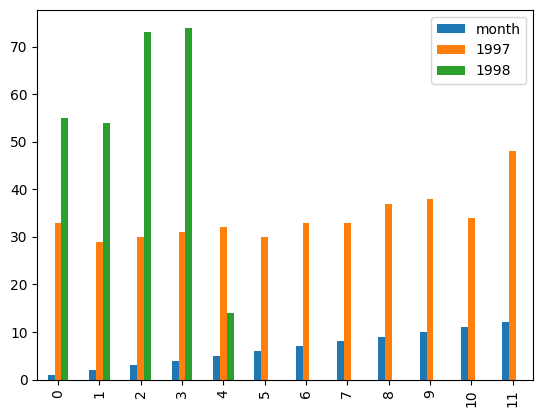

In [32]:
#чтобы лучше понять, что я имею ввиду, посчитаем кол-во заказов а не выручку
df_o_1997 = df_o[df_o.year== 1997].groupby('month').OrderID.count().reset_index().copy()
df_o_1998 = df_o[df_o.year== 1998].groupby('month').OrderID.count().reset_index().copy()
#переименнуем столбцы с кол-вом заказов
df_o_1998 = df_o_1998.rename(columns = {'OrderID':'1998'})
df_o_1997 = df_o_1997.rename(columns = {'OrderID':'1997'})

#объединим в один датафрейм
df_f = df_o_1997.merge(df_o_1998, how ='left',on = 'month')

#график распознал месяц не как подписи данных, а как число. А в подписях данных не месяцы, а индексы
df_f.plot(kind= 'bar')

<Axes: xlabel='month'>

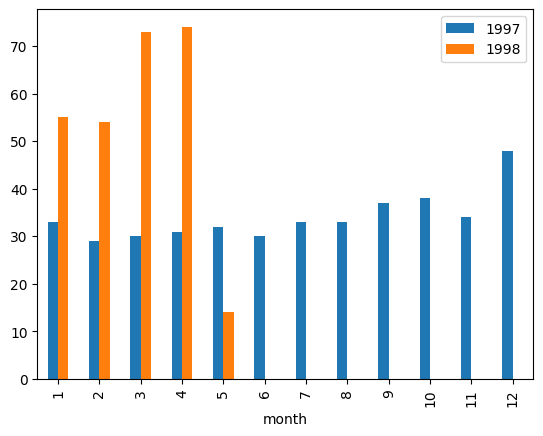

In [33]:
#указываем что месяцы идут по оси x вручную, чтобы этого избежать
df_f.plot(kind= 'bar', x = 'month')

In [38]:
#обнулим изменения
df_o = pd.read_csv('/content/drive/MyDrive/Orders.csv', sep = ';', parse_dates=['OrderDate', 'RequiredDate', 'ShippedDate'])

#выводим 5 строк с df_od
df_od.head()

,OrderID,ProductID,UnitPrice,Quantity,Discount,revenue
0,10248,11,14.0,12,0.0,168.0
1,10248,42,9.8,10,0.0,98.0
2,10248,72,34.8,5,0.0,174.0
3,10249,14,18.6,9,0.0,167.4
4,10249,51,42.4,40,0.0,1696.0


In [36]:
#считаем чистую выручку по каждому заказу
df_od['revenue'] = df_od['Quantity']*df_od['UnitPrice']*(1- df_od['Discount'])
df_od_final  = df_od.groupby('OrderID').revenue.sum().reset_index()

#смотрим что получилось
df_od_final

,OrderID,revenue
0,10248,440.0000
1,10249,1863.4000
2,10250,1552.6000
3,10251,654.0600
4,10252,3597.9000
...,...,...
825,11073,300.0000
826,11074,232.0850
827,11075,498.1000
828,11076,792.7500


In [40]:
#добавляем выручку в df_o
df_o = df_o.merge(df_od_final)

#смотрим добавился ли столбец
df_o

,OrderID,CustomerID,EmployeeID,OrderDate,RequiredDate,ShippedDate,Freight,revenue
0,10248,VINET,5,1996-07-04,1996-08-01,1996-07-16,32.38,440.0000
1,10249,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,11.61,1863.4000
2,10250,HANAR,4,1996-07-08,1996-08-05,1996-07-12,65.83,1552.6000
3,10251,VICTE,3,1996-07-08,1996-08-05,1996-07-15,41.34,654.0600
4,10252,SUPRD,4,1996-07-09,1996-08-06,1996-07-11,51.30,3597.9000
...,...,...,...,...,...,...,...,...
825,11073,PERIC,2,1998-05-05,1998-06-02,NaT,24.95,300.0000
826,11074,SIMOB,7,1998-05-06,1998-06-03,NaT,18.44,232.0850
827,11075,RICSU,8,1998-05-06,1998-06-03,NaT,6.19,498.1000
828,11076,BONAP,4,1998-05-06,1998-06-03,NaT,38.28,792.7500


<Axes: xlabel='Freight', ylabel='revenue'>

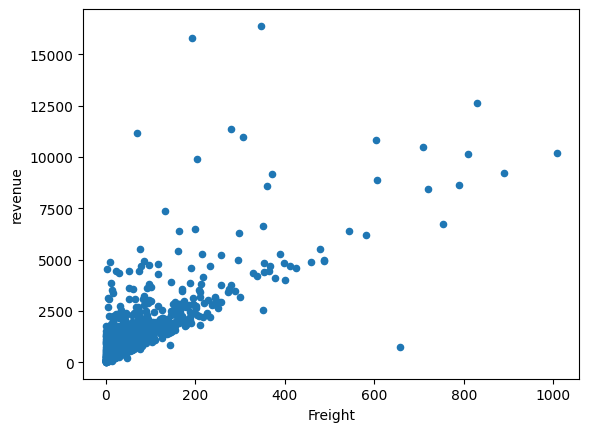

In [42]:
#строим scatter plot. Зависимость чистой выручки от веса заказа
df_o.plot(kind= 'scatter', x = 'Freight', y = 'revenue')

In [ ]:
#Можно сделать вывод о том, что чистая выручка зависит от веса заказа - чем больше вес, тем больше выручка